# Multivariate Statistics Final Project
**Dataset:** WHO Life Expectancy Data (2000–2015)  
**Source:** [Kaggle – Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)


## Imports & Configuration

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy import stats
from scipy.stats import shapiro, normaltest, probplot
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess

os.makedirs("figures", exist_ok=True)
plt.rcParams['figure.dpi'] = 120
print("All libraries loaded successfully.")


All libraries loaded successfully.


## Dataset Description

The WHO Life Expectancy dataset covers 193 countries over 16 years (2000–2015) and combines health,
economic, and social indicators. It is rich, real-world, and the outcome variable (life expectancy)
is inherently multidimensional, making it ideal for multivariate analysis. The mix of developed and
developing countries also creates interesting heterogeneity to explore.


In [2]:
df = pd.read_csv("Life Expectancy Data.csv")
df.columns = df.columns.str.strip()

col_rename = {
    "Life expectancy": "Life_expectancy",
    "Adult Mortality": "Adult_Mortality",
    "infant deaths": "Infant_deaths",
    "percentage expenditure": "Pct_expenditure",
    "Hepatitis B": "Hepatitis_B",
    "Measles": "Measles",
    "BMI": "BMI",
    "under-five deaths": "Under5_deaths",
    "Total expenditure": "Total_expenditure",
    "Diphtheria": "Diphtheria",
    "HIV/AIDS": "HIV_AIDS",
    "thinness  1-19 years": "Thinness_1_19",
    "thinness 5-9 years": "Thinness_5_9",
    "Income composition of resources": "Income_composition",
}
df.rename(columns=col_rename, inplace=True)

numeric_cols = [
    "Life_expectancy", "Adult_Mortality", "Infant_deaths", "Alcohol",
    "Pct_expenditure", "Hepatitis_B", "Measles", "BMI", "Under5_deaths",
    "Polio", "Total_expenditure", "Diphtheria", "HIV_AIDS", "GDP",
    "Population", "Thinness_1_19", "Thinness_5_9", "Income_composition", "Schooling"
]

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nMissing values:\n{df[numeric_cols].isnull().sum().to_string()}")

df_clean = df[numeric_cols + ["Country", "Year", "Status"]].dropna()
print(f"\nAfter dropping NAs: {df_clean.shape[0]} rows")


Shape: 2938 rows x 22 columns

Missing values:
Life_expectancy        10
Adult_Mortality        10
Infant_deaths           0
Alcohol               194
Pct_expenditure         0
Hepatitis_B           553
Measles                 0
BMI                    34
Under5_deaths           0
Polio                  19
Total_expenditure     226
Diphtheria             19
HIV_AIDS                0
GDP                   448
Population            652
Thinness_1_19          34
Thinness_5_9           34
Income_composition    167
Schooling             163

After dropping NAs: 1649 rows


In [3]:
df_clean[numeric_cols].describe().round(2)


,Life_expectancy,Adult_Mortality,Infant_deaths,Alcohol,Pct_expenditure,Hepatitis_B,Measles,BMI,Under5_deaths,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,Thinness_1_19,Thinness_5_9,Income_composition,Schooling
count,1649.0,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1649.00,1.649000e+03,1649.00,1649.00,1649.00,1649.00
mean,69.3,168.22,32.55,4.53,698.97,79.22,2224.49,38.13,44.22,83.56,5.96,84.16,1.98,5566.03,1.465363e+07,4.85,4.91,0.63,12.12
std,8.8,125.31,120.85,4.03,1759.23,25.60,10085.80,19.75,162.90,22.45,2.30,21.58,6.03,11475.90,7.046039e+07,4.60,4.65,0.18,2.80
min,44.0,1.00,0.00,0.01,0.00,2.00,0.00,2.00,0.00,3.00,0.74,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,4.20
25%,64.4,77.00,1.00,0.81,37.44,74.00,0.00,19.50,1.00,81.00,4.41,82.00,0.10,462.15,1.918970e+05,1.60,1.70,0.51,10.30
50%,71.7,148.00,3.00,3.79,145.10,89.00,15.00,43.70,4.00,93.00,5.84,92.00,0.10,1592.57,1.419631e+06,3.00,3.20,0.67,12.30
75%,75.0,227.00,22.00,7.34,509.39,96.00,373.00,55.80,29.00,97.00,7.47,97.00,0.70,4718.51,7.658972e+06,7.10,7.10,0.75,14.00
max,89.0,723.00,1600.00,17.87,18961.35,99.00,131441.00,77.10,2100.00,99.00,14.39,99.00,50.60,119172.74,1.293859e+09,27.20,28.20,0.94,20.70


## Pairwise Scatter Plots

1. **Basic** - black = Developed, red = Developing  
2. **LOWESS smoothing** - non-parametric trend line  
3. **Confidence ellipses** - 2-SD ellipses per group


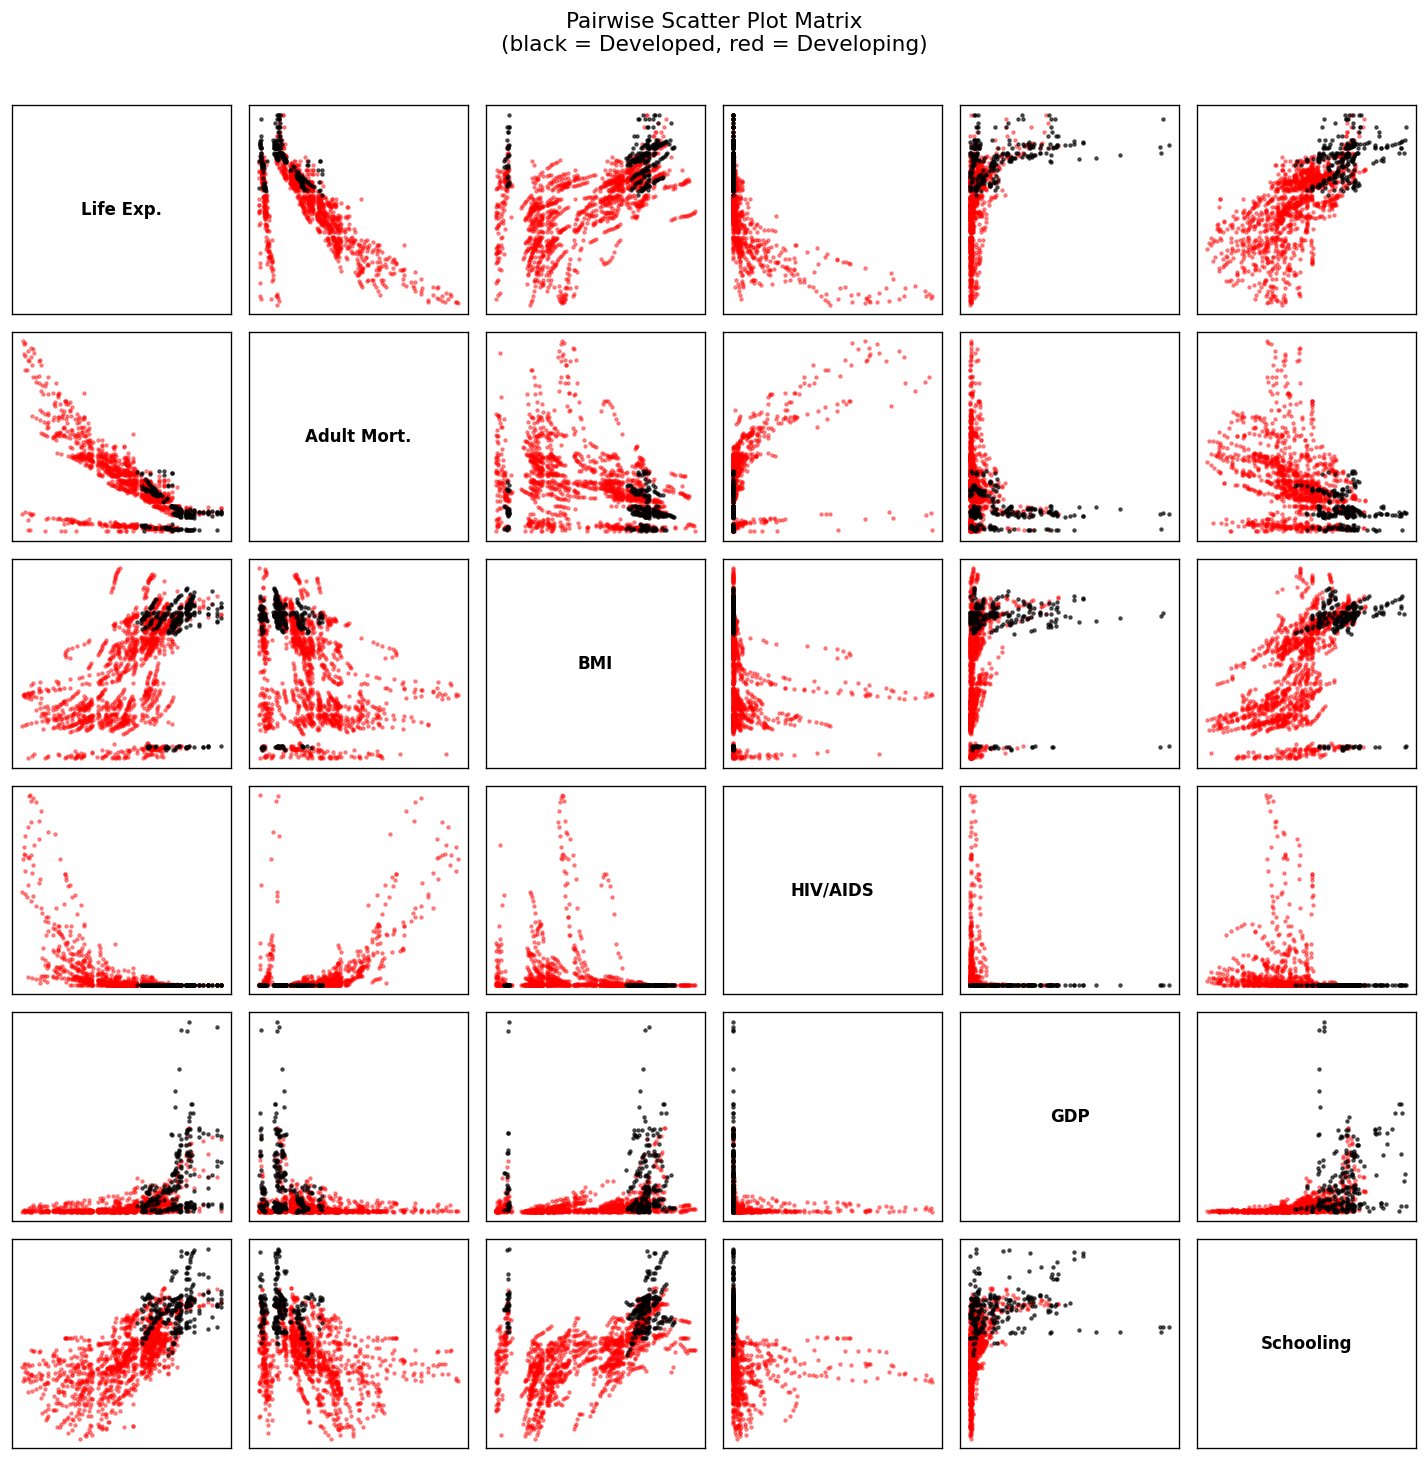

In [ ]:
key_vars = ["Life_expectancy", "Adult_Mortality", "BMI", "HIV_AIDS", "GDP", "Schooling"]
labels   = ["Life Exp.", "Adult Mort.", "BMI", "HIV/AIDS", "GDP", "Schooling"]
df_pairs  = df_clean[key_vars].copy()
developed  = df_clean["Status"] == "Developed"
developing = df_clean["Status"] == "Developing"

# Plot 1: Basic (black / red by status)
fig, axes = plt.subplots(len(key_vars), len(key_vars), figsize=(12, 12))
fig.suptitle("Pairwise Scatter Plot Matrix\n(black = Developed, red = Developing)",
             fontsize=13, y=1.01)

for i, (vi, li) in enumerate(zip(key_vars, labels)):
    for j, (vj, lj) in enumerate(zip(key_vars, labels)):
        ax = axes[i][j]
        if i == j:
            ax.text(0.5, 0.5, li, transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.scatter(df_clean.loc[developing, vj], df_clean.loc[developing, vi],
                       s=3, c='red', alpha=0.4)
            ax.scatter(df_clean.loc[developed, vj], df_clean.loc[developed, vi],
                       s=3, c='black', alpha=0.6)
            ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("figures/01_scatter_matrix_basic.png", bbox_inches='tight')
plt.show()


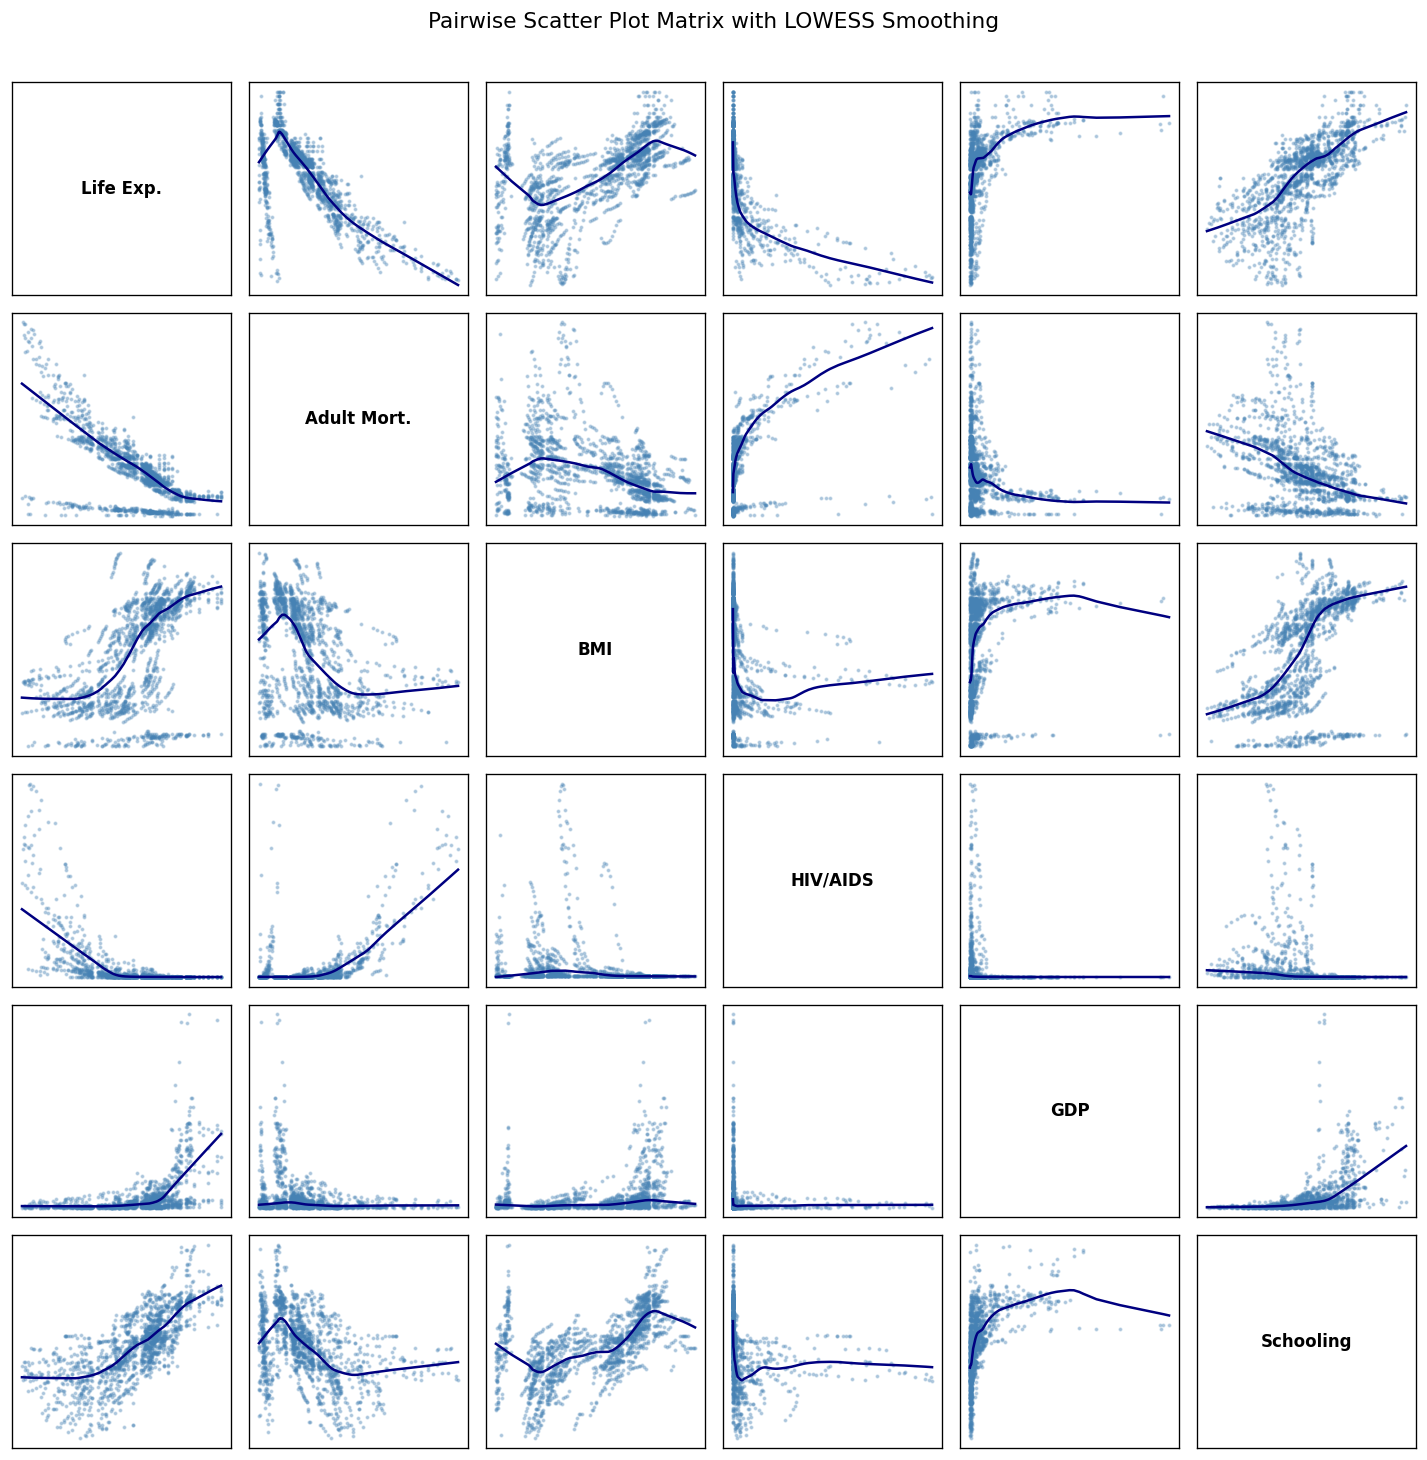

In [ ]:
# Plot 2: LOWESS smoothing
fig, axes = plt.subplots(len(key_vars), len(key_vars), figsize=(12, 12))
fig.suptitle("Pairwise Scatter Plot Matrix with LOWESS Smoothing",
             fontsize=13, y=1.01)

for i, (vi, li) in enumerate(zip(key_vars, labels)):
    for j, (vj, lj) in enumerate(zip(key_vars, labels)):
        ax = axes[i][j]
        if i == j:
            ax.text(0.5, 0.5, li, transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            x, y = df_pairs[vj].values, df_pairs[vi].values
            ax.scatter(x, y, s=2, c='steelblue', alpha=0.3)
            order = np.argsort(x)
            try:
                sm_pts = lowess(y[order], x[order], frac=0.4, return_sorted=True)
                ax.plot(sm_pts[:, 0], sm_pts[:, 1], 'navy', lw=1.5)
            except Exception:
                pass
            ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("figures/02_scatter_matrix_lowess.png", bbox_inches='tight')
plt.show()


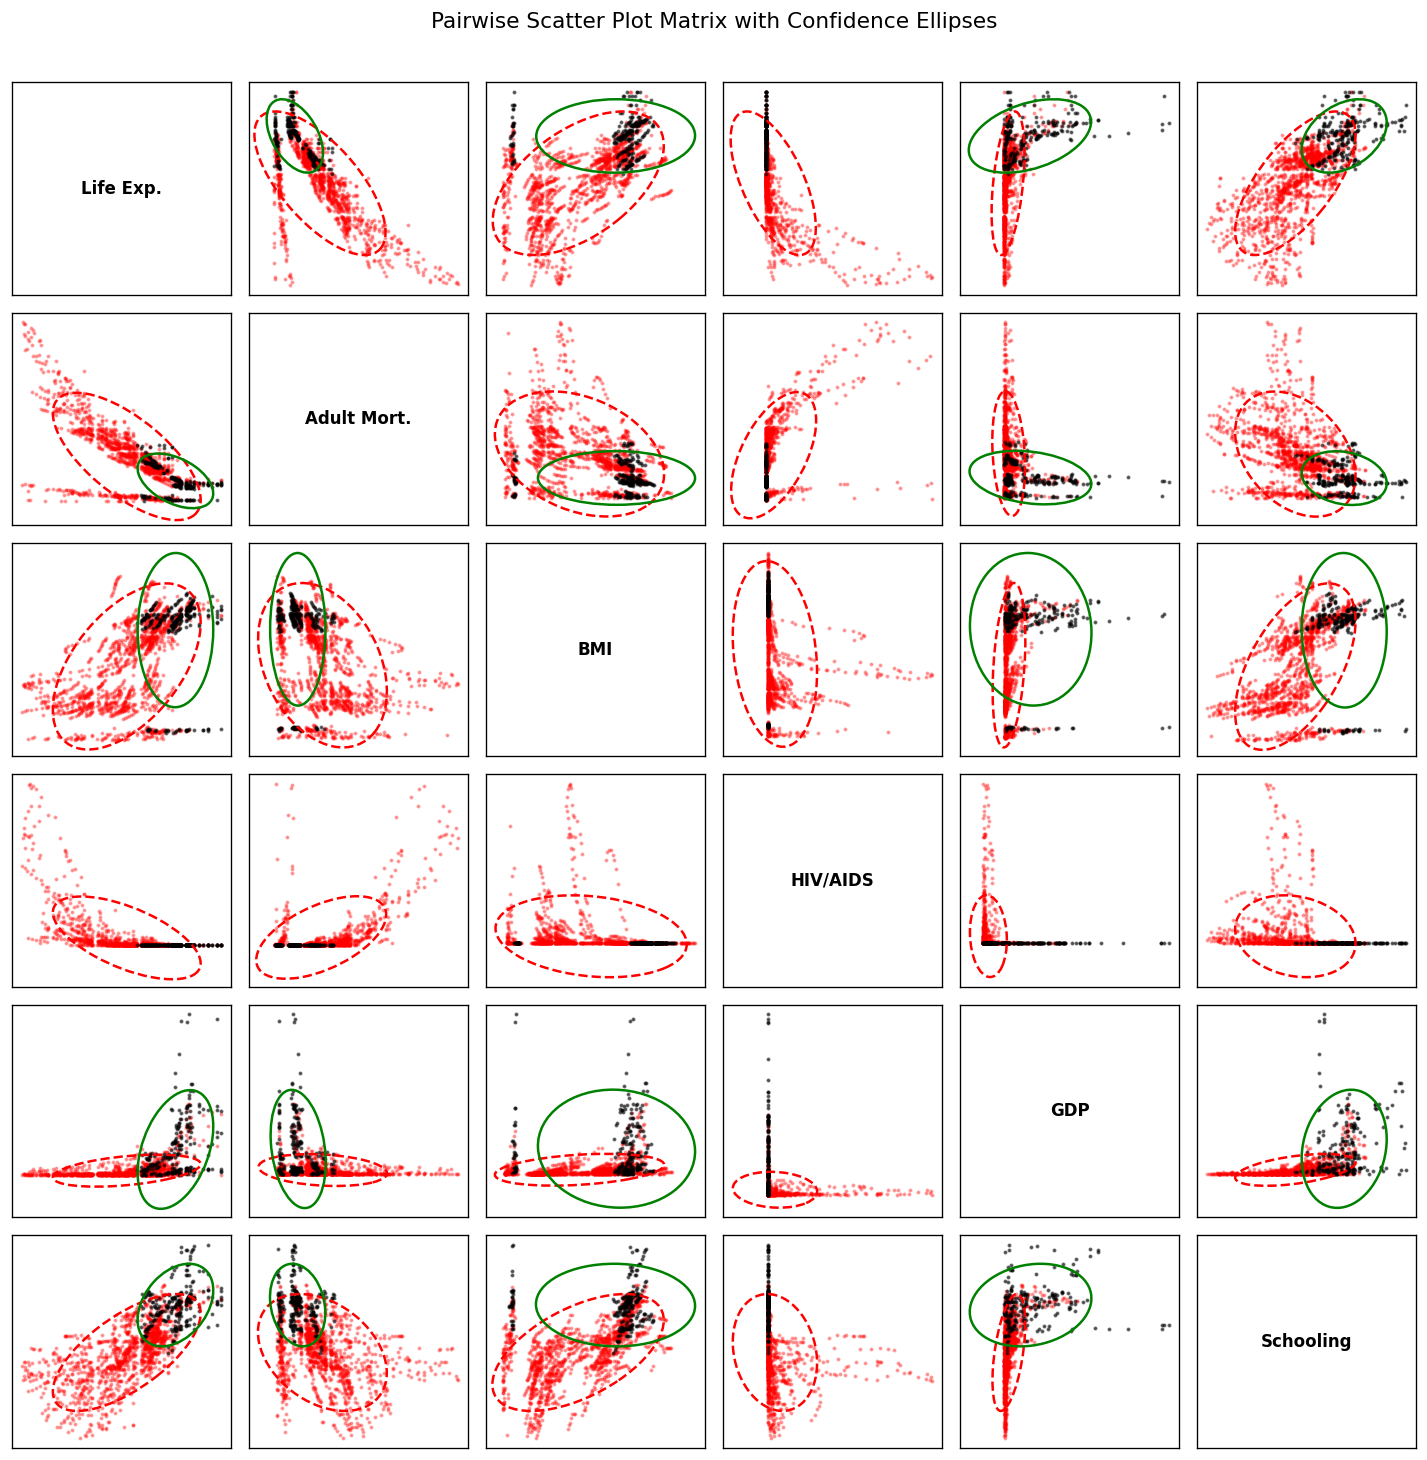

In [ ]:
# Plot 3: Confidence ellipses
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ellipse = Ellipse((0, 0), width=np.sqrt(1 + pearson)*2,
                      height=np.sqrt(1 - pearson)*2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (plt.matplotlib.transforms.Affine2D()
              .rotate_deg(45)
              .scale(scale_x, scale_y)
              .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

fig, axes = plt.subplots(len(key_vars), len(key_vars), figsize=(12, 12))
fig.suptitle("Pairwise Scatter Plot Matrix with Confidence Ellipses",
             fontsize=13, y=1.01)

for i, (vi, li) in enumerate(zip(key_vars, labels)):
    for j, (vj, lj) in enumerate(zip(key_vars, labels)):
        ax = axes[i][j]
        if i == j:
            ax.text(0.5, 0.5, li, transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            xdv = df_clean.loc[developing, vj].values
            ydv = df_clean.loc[developing, vi].values
            xd  = df_clean.loc[developed, vj].values
            yd  = df_clean.loc[developed, vi].values
            ax.scatter(xdv, ydv, s=2, c='red',   alpha=0.3)
            ax.scatter(xd,  yd,  s=2, c='black', alpha=0.5)
            confidence_ellipse(xdv, ydv, ax, n_std=2,
                               edgecolor='red',   facecolor='none', lw=1.5, linestyle='--')
            confidence_ellipse(xd,  yd,  ax, n_std=2,
                               edgecolor='green', facecolor='none', lw=1.5)
            ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("figures/03_scatter_matrix_ellipses.png", bbox_inches='tight')
plt.show()


## Gaussian Distribution Assessment

For each key variable we show:
- **Histogram + KDE** vs. fitted Normal curve  
- **Q-Q plot** (Quantile-Quantile against Normal)  
- **Shapiro-Wilk** and **D'Agostino K²** test results


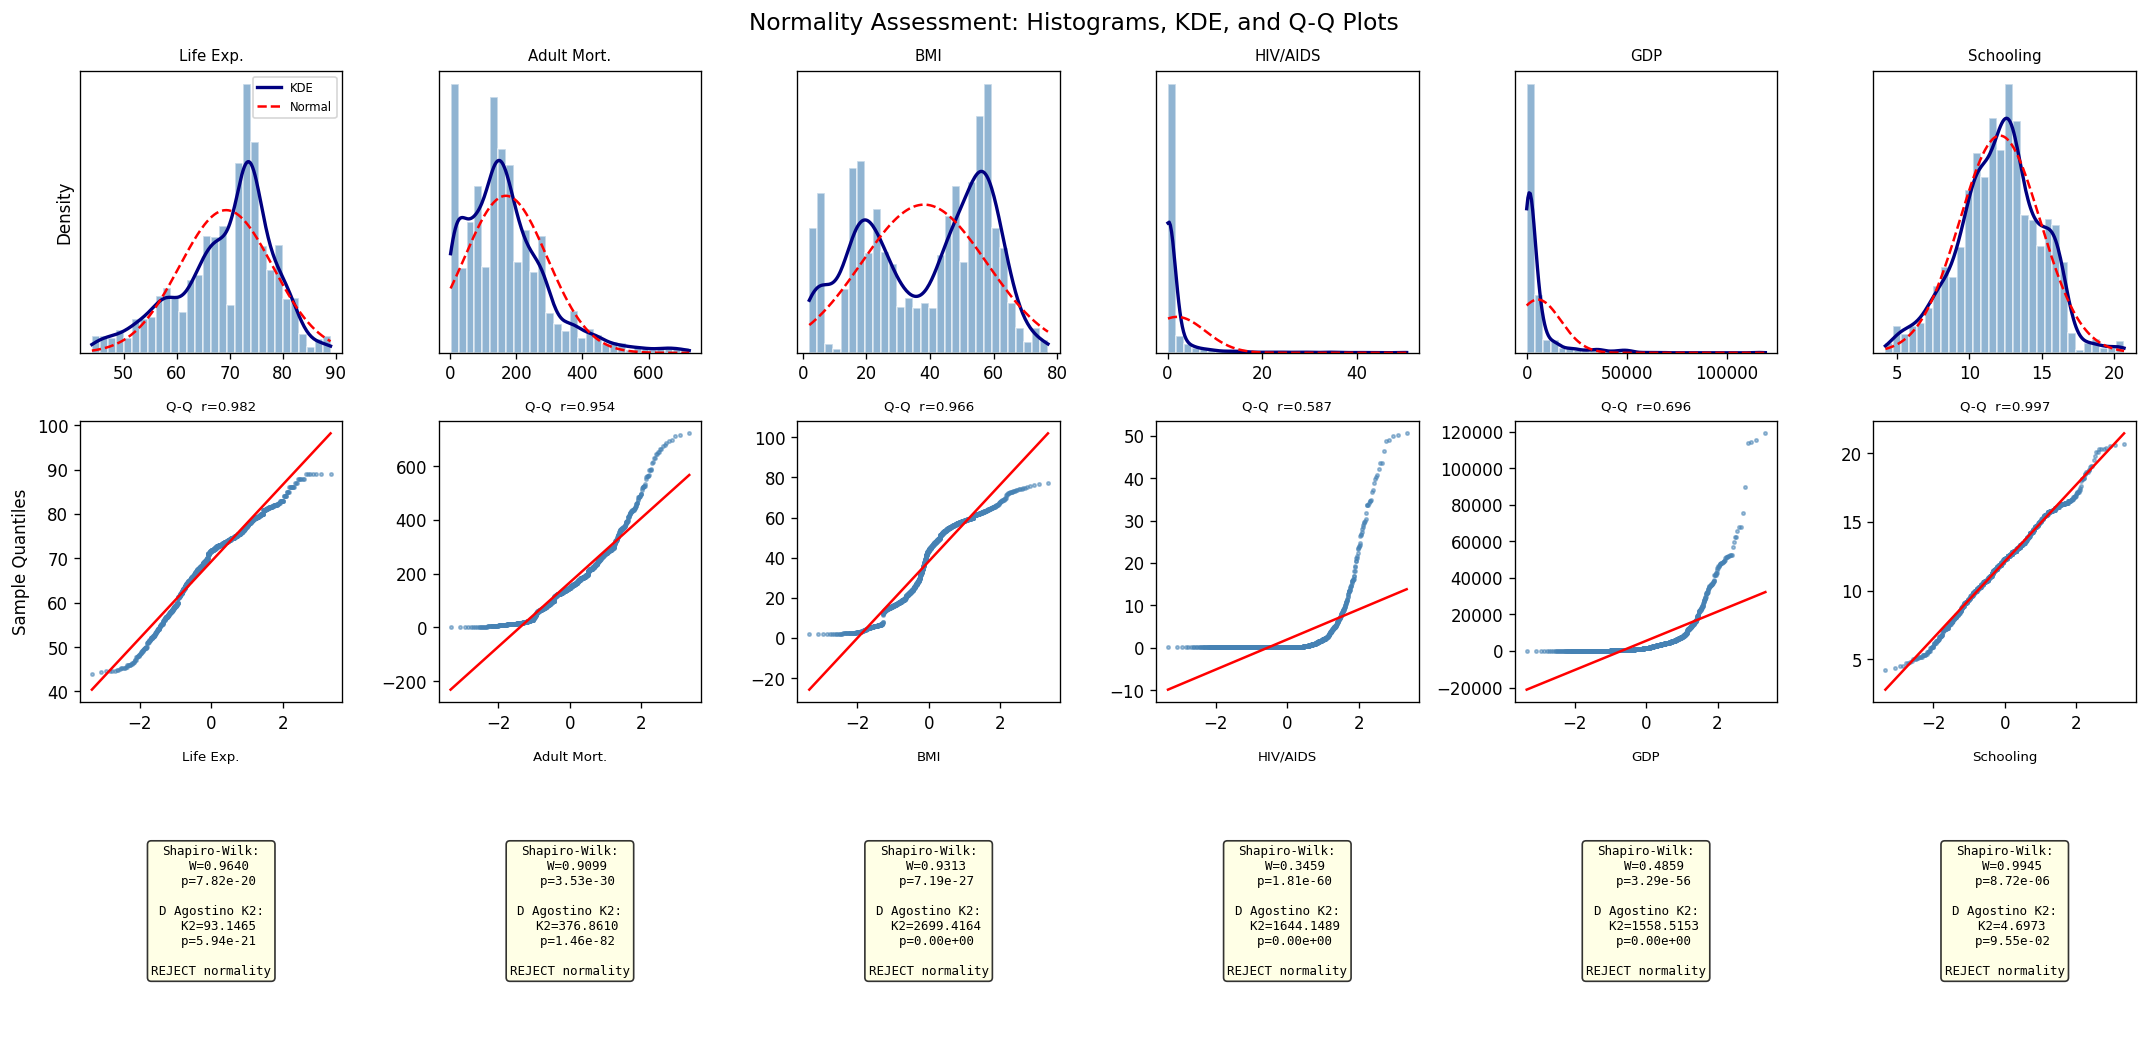

,Shapiro p,K2 p,Normal?
Variable,,,
Life Exp.,7.82e-20,5.94e-21,REJECT normality
Adult Mort.,3.53e-30,1.46e-82,REJECT normality
BMI,7.19e-27,0.00e+00,REJECT normality
HIV/AIDS,1.81e-60,0.00e+00,REJECT normality
GDP,3.29e-56,0.00e+00,REJECT normality
Schooling,8.72e-06,9.55e-02,REJECT normality


In [7]:
fig, axes = plt.subplots(3, len(key_vars), figsize=(18, 9))
fig.suptitle("Normality Assessment: Histograms, KDE, and Q-Q Plots", fontsize=14)

results = []
for j, (var, lbl) in enumerate(zip(key_vars, labels)):
    data = df_clean[var].dropna().values
    kde_x = np.linspace(data.min(), data.max(), 200)

    # Row 0 – histogram + KDE + Normal
    ax1 = axes[0][j]
    ax1.hist(data, bins=30, density=True, color='steelblue', alpha=0.6, edgecolor='white')
    ax1.plot(kde_x, stats.gaussian_kde(data)(kde_x), 'navy', lw=2, label='KDE')
    ax1.plot(kde_x, stats.norm.pdf(kde_x, data.mean(), data.std()), 'r--', lw=1.5, label='Normal')
    ax1.set_title(lbl, fontsize=9); ax1.set_yticks([])
    if j == 0:
        ax1.set_ylabel("Density"); ax1.legend(fontsize=7)

    # Row 1 – Q-Q
    ax2 = axes[1][j]
    (osm, osr), (slope, intercept, r) = probplot(data, dist="norm")
    ax2.plot(osm, osr, 'o', ms=2, color='steelblue', alpha=0.5)
    ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
    ax2.set_title(f"Q-Q  r={r:.3f}", fontsize=8)
    if j == 0: ax2.set_ylabel("Sample Quantiles")

    # Row 2 – test statistics
    ax3 = axes[2][j]
    sample = data[:5000]
    stat_sw, p_sw = shapiro(sample)
    stat_k2, p_k2 = normaltest(data)
    ax3.axis('off')
    verdict = 'REJECT normality' if p_sw < 0.05 else 'Cannot reject'
    txt = (f"Shapiro-Wilk:\n  W={stat_sw:.4f}\n  p={p_sw:.2e}\n\n"
           f"D Agostino K2:\n  K2={stat_k2:.4f}\n  p={p_k2:.2e}\n\n{verdict}")
    ax3.text(0.5, 0.5, txt, transform=ax3.transAxes, ha='center', va='center',
             fontsize=7.5, family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax3.set_title(lbl, fontsize=8)
    results.append({"Variable": lbl, "Shapiro p": f"{p_sw:.2e}",
                    "K2 p": f"{p_k2:.2e}", "Normal?": verdict})

plt.tight_layout()
plt.savefig("figures/04_normality_assessment.png", bbox_inches='tight')
plt.show()

pd.DataFrame(results).set_index("Variable")


## Linear Regression

**Dependent variable: `Life_expectancy`**  
Chosen because it is the most natural summary outcome of all health, economic, and social factors
in the dataset, and it has the strongest correlations with the widest range of predictors.


In [8]:
feature_cols = [
    "Adult_Mortality", "Alcohol", "Pct_expenditure", "Hepatitis_B",
    "BMI", "Polio", "Total_expenditure", "Diphtheria", "HIV_AIDS",
    "GDP", "Thinness_1_19", "Income_composition", "Schooling"
]

y    = df_clean["Life_expectancy"].values
X_df = df_clean[feature_cols].copy()

print("Correlation of features with Life Expectancy:")
corr_series = X_df.corrwith(df_clean["Life_expectancy"]).sort_values(key=abs, ascending=False)
display(corr_series.round(4).to_frame("Pearson r"))


Correlation of features with Life Expectancy:


,Pearson r
Schooling,0.7276
Income_composition,0.7211
Adult_Mortality,-0.7025
HIV_AIDS,-0.5922
BMI,0.5420
Thinness_1_19,-0.4578
GDP,0.4413
Pct_expenditure,0.4096
Alcohol,0.4027
Diphtheria,0.3413


In [9]:
# OLS full model
X_sm = sm.add_constant(X_df)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     595.6
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        16:49:23   Log-Likelihood:                -4484.7
No. Observations:                1649   AIC:                             8997.
Df Residuals:                    1635   BIC:                             9073.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 52.0058      0

In [10]:
# VIF
vif_data = pd.DataFrame({
    "Feature": feature_cols,
    "VIF": [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
})
print("Variance Inflation Factors:")
display(vif_data.sort_values("VIF", ascending=False).reset_index(drop=True))


Variance Inflation Factors:


,Feature,VIF
0,Schooling,56.153976
1,Income_composition,36.887784
2,Diphtheria,32.743036
3,Polio,24.792085
4,Hepatitis_B,16.932782
5,GDP,16.538205
6,Pct_expenditure,14.815044
7,BMI,8.101355
8,Total_expenditure,8.075239
9,Adult_Mortality,3.941748


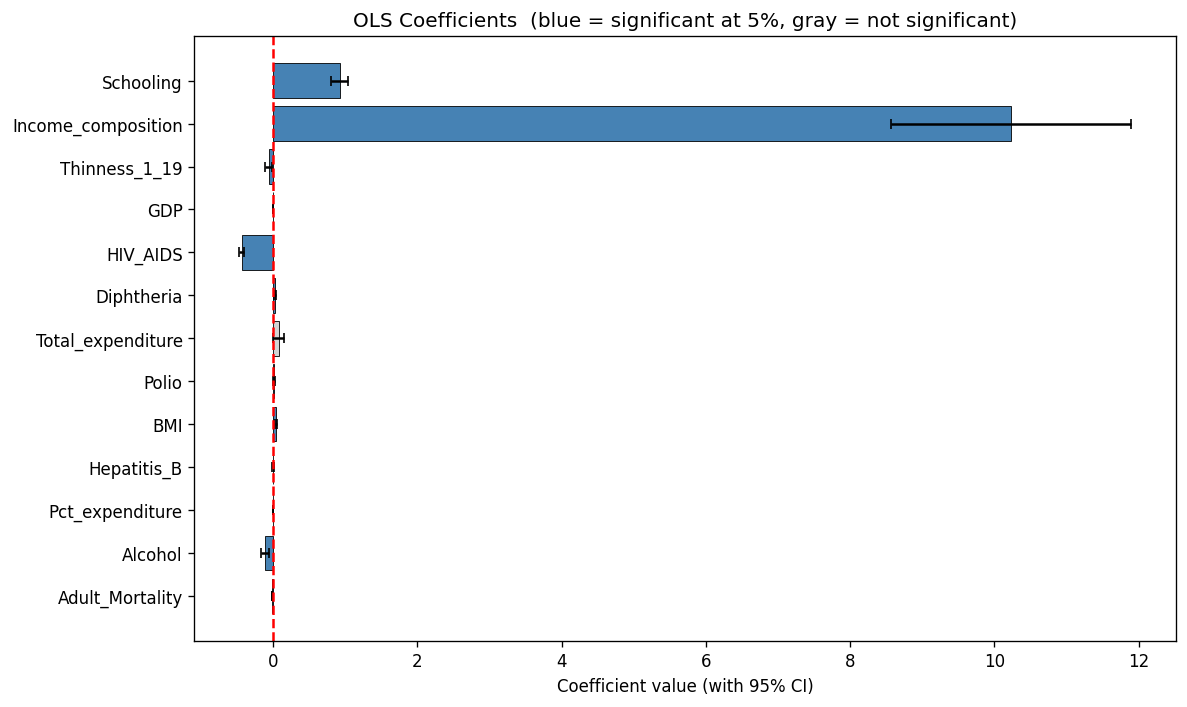

In [11]:
# Coefficient plot
fig, ax = plt.subplots(figsize=(10, 6))
coef   = ols_model.params[1:]
ci     = ols_model.conf_int().iloc[1:]
colors = ['steelblue' if p < 0.05 else 'lightgray' for p in ols_model.pvalues[1:]]
y_pos  = range(len(coef))
ax.barh(y_pos, coef.values,
        xerr=[(coef.values - ci.iloc[:, 0].values),
              (ci.iloc[:, 1].values - coef.values)],
        color=colors, edgecolor='black', lw=0.5, capsize=3)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.set_yticks(list(y_pos)); ax.set_yticklabels(coef.index)
ax.set_xlabel("Coefficient value (with 95% CI)")
ax.set_title("OLS Coefficients  (blue = significant at 5%, gray = not significant)")
plt.tight_layout()
plt.savefig("figures/05_ols_coefficients.png", bbox_inches='tight')
plt.show()


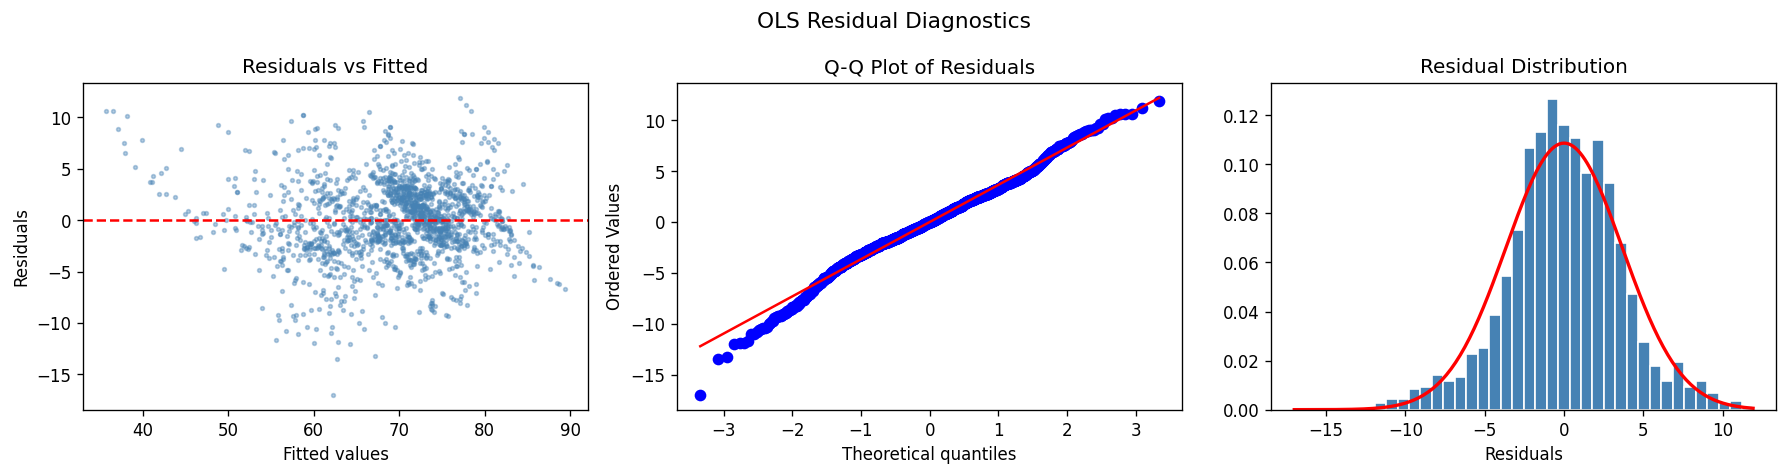

In [12]:
# Residual diagnostics
fitted    = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("OLS Residual Diagnostics", fontsize=13)

axes[0].scatter(fitted, residuals, s=5, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

kde_x = np.linspace(residuals.min(), residuals.max(), 200)
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', density=True)
axes[2].plot(kde_x, stats.norm.pdf(kde_x, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[2].set_xlabel("Residuals"); axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("figures/06_residual_diagnostics.png", bbox_inches='tight')
plt.show()


## Variable Selection

Two complementary methods:
- **LASSO with 10-fold CV** - regularization shrinks uninformative coefficients to zero  
- **Forward stepwise selection** - greedy inclusion by p-value < 0.05


In [13]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=42)
lasso_cv.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_cols)

print(f"LASSO optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"Features selected (non-zero): {(lasso_coefs != 0).sum()} / {len(feature_cols)}")
print()
display(lasso_coefs[lasso_coefs != 0]
        .sort_values(key=abs, ascending=False)
        .round(4).to_frame("LASSO coef (standardized)"))
print("Zeroed out:", list(lasso_coefs[lasso_coefs == 0].index))


LASSO optimal alpha: 0.209535
Features selected (non-zero): 10 / 13



,LASSO coef (standardized)
HIV_AIDS,-2.5197
Schooling,2.4583
Adult_Mortality,-2.2585
Income_composition,1.7873
BMI,0.6401
Pct_expenditure,0.4860
Diphtheria,0.2866
Thinness_1_19,-0.1661
GDP,0.1275
Polio,0.1187


Zeroed out: ['Alcohol', 'Hepatitis_B', 'Total_expenditure']


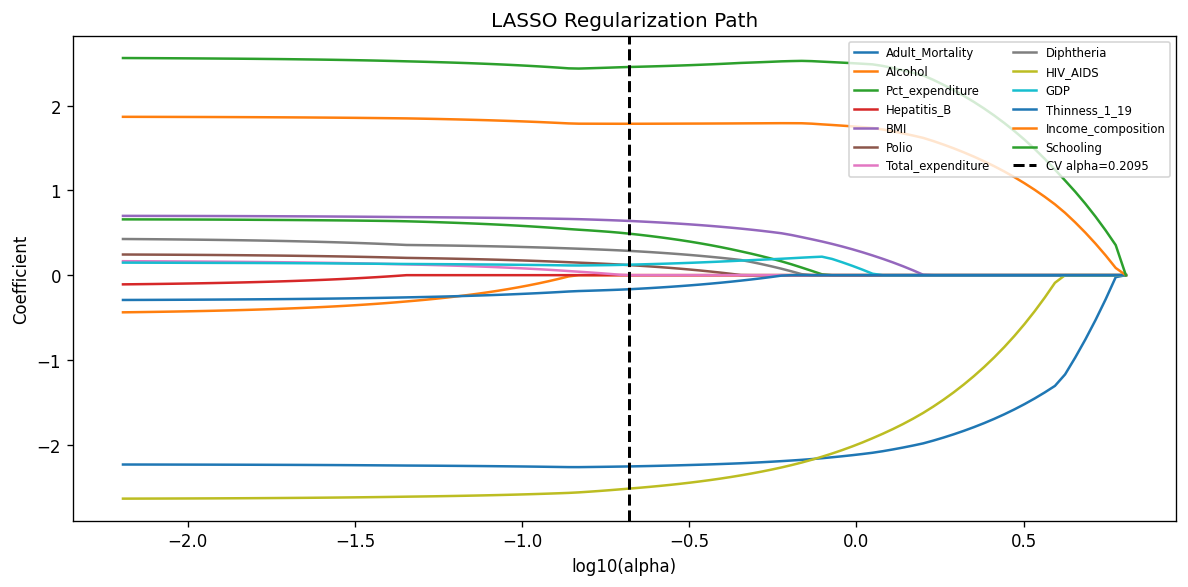

In [14]:
# LASSO path
alphas_path, coefs_path, _ = lasso_path(X_scaled, y, eps=1e-3)
fig, ax = plt.subplots(figsize=(10, 5))
for i, label in enumerate(feature_cols):
    ax.plot(np.log10(alphas_path), coefs_path[i], lw=1.5, label=label)
ax.axvline(np.log10(lasso_cv.alpha_), color='black', ls='--', lw=1.8,
           label=f'CV alpha={lasso_cv.alpha_:.4f}')
ax.set_xlabel("log10(alpha)"); ax.set_ylabel("Coefficient")
ax.set_title("LASSO Regularization Path")
ax.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("figures/07_lasso_path.png", bbox_inches='tight')
plt.show()


In [15]:
# Forward stepwise selection
def forward_selection(X, y, threshold_in=0.05):
    included, remaining = [], list(X.columns)
    while remaining:
        pvalues = {col: sm.OLS(y, sm.add_constant(X[included + [col]])).fit().pvalues[col]
                   for col in remaining}
        best = min(pvalues, key=pvalues.get)
        if pvalues[best] < threshold_in:
            included.append(best); remaining.remove(best)
        else:
            break
    return included

selected_forward = forward_selection(X_df, y)
model_fwd = sm.OLS(y, sm.add_constant(X_df[selected_forward])).fit()

print(f"Forward selection chose {len(selected_forward)} variables:")
print(selected_forward)
print(f"\nR2={model_fwd.rsquared:.4f}  Adj-R2={model_fwd.rsquared_adj:.4f}  AIC={model_fwd.aic:.2f}")


Forward selection chose 10 variables:
['Schooling', 'HIV_AIDS', 'Adult_Mortality', 'Income_composition', 'Pct_expenditure', 'BMI', 'Diphtheria', 'Alcohol', 'Thinness_1_19', 'Polio']

R2=0.8252  Adj-R2=0.8241  AIC=8995.80


## Principal Component Analysis (PCA)


In [ ]:
pca_cols    = feature_cols + ["Life_expectancy"]
X_pca_df    = df_clean[pca_cols].copy()
X_pca_scaled = StandardScaler().fit_transform(X_pca_df.values)

pca = PCA()
pca.fit(X_pca_scaled)
explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Summary table
n_comp_show = min(14, len(explained))
pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_comp_show)],
    "Explained %": (explained[:n_comp_show]*100).round(2),
    "Cumulative %": (cumulative[:n_comp_show]*100).round(2)
}).set_index("PC")
display(pca_table)


,Explained %,Cumulative %
PC,,
PC1,38.14,38.14
PC2,13.11,51.25
PC3,11.31,62.56
PC4,8.43,70.98
PC5,6.22,77.20
PC6,4.90,82.09
PC7,3.66,85.76
PC8,3.55,89.30
PC9,2.90,92.20


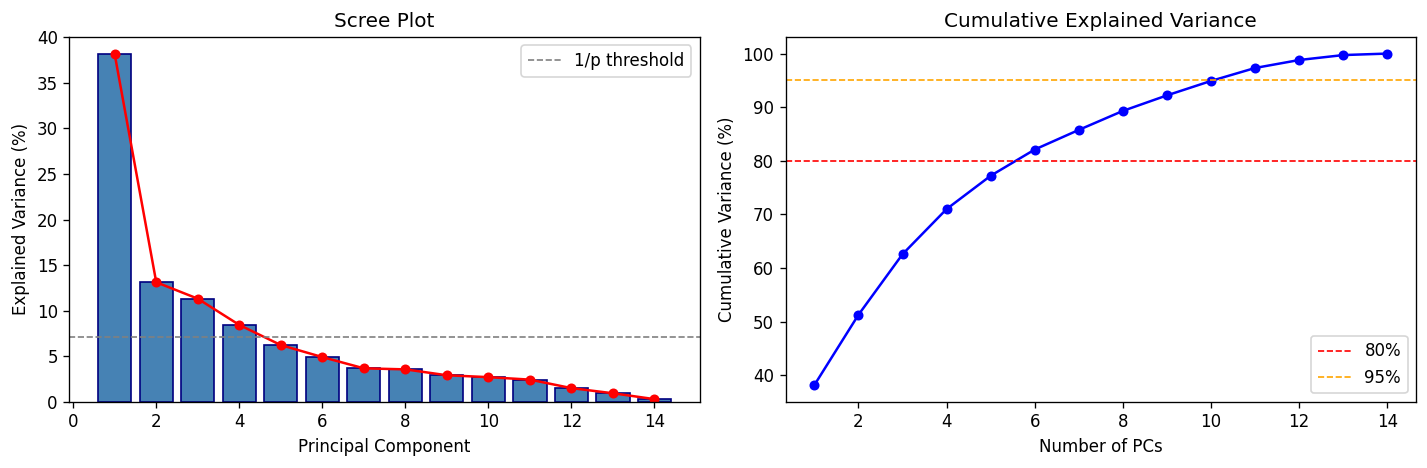

In [17]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n = min(14, len(explained))

axes[0].bar(range(1, n+1), explained[:n]*100, color='steelblue', edgecolor='navy')
axes[0].plot(range(1, n+1), explained[:n]*100, 'ro-', ms=5)
axes[0].axhline(100/len(pca_cols), color='gray', ls='--', lw=1, label='1/p threshold')
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot"); axes[0].legend()

axes[1].plot(range(1, n+1), cumulative[:n]*100, 'bo-', ms=5)
axes[1].axhline(80, color='red',    ls='--', lw=1, label='80%')
axes[1].axhline(95, color='orange', ls='--', lw=1, label='95%')
axes[1].set_xlabel("Number of PCs"); axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance"); axes[1].legend()

plt.tight_layout()
plt.savefig("figures/08_pca_scree.png", bbox_inches='tight')
plt.show()


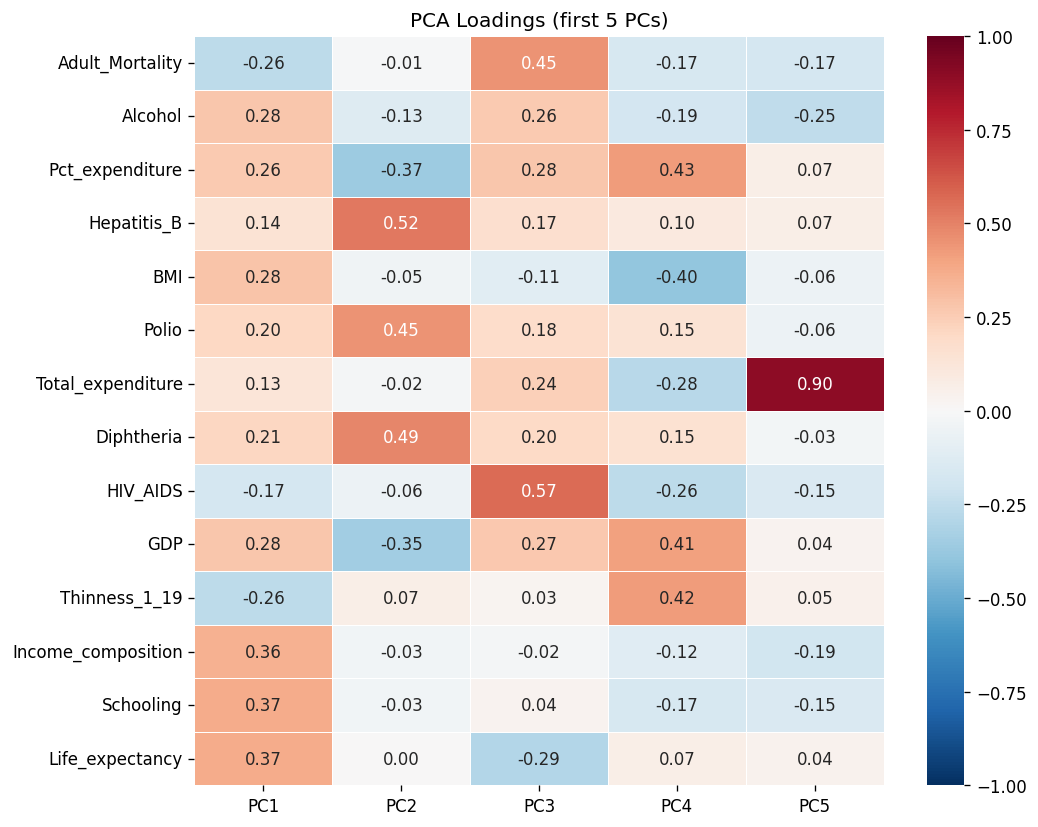

In [18]:
# Loadings heatmap (first 5 PCs)
n_pcs = 5
loadings = pd.DataFrame(
    pca.components_[:n_pcs].T,
    index=pca_cols,
    columns=[f"PC{i+1}" for i in range(n_pcs)]
)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("PCA Loadings (first 5 PCs)")
plt.tight_layout()
plt.savefig("figures/08b_pca_loadings_heatmap.png", bbox_inches='tight')
plt.show()


## Correlation Circle (Variables Factor Map)

Each arrow shows the correlation of an original variable with PC1 (x-axis) and PC2 (y-axis).  
- Arrows pointing in the same direction → positively correlated variables  
- Arrows near the circle edge → well represented by the first two PCs


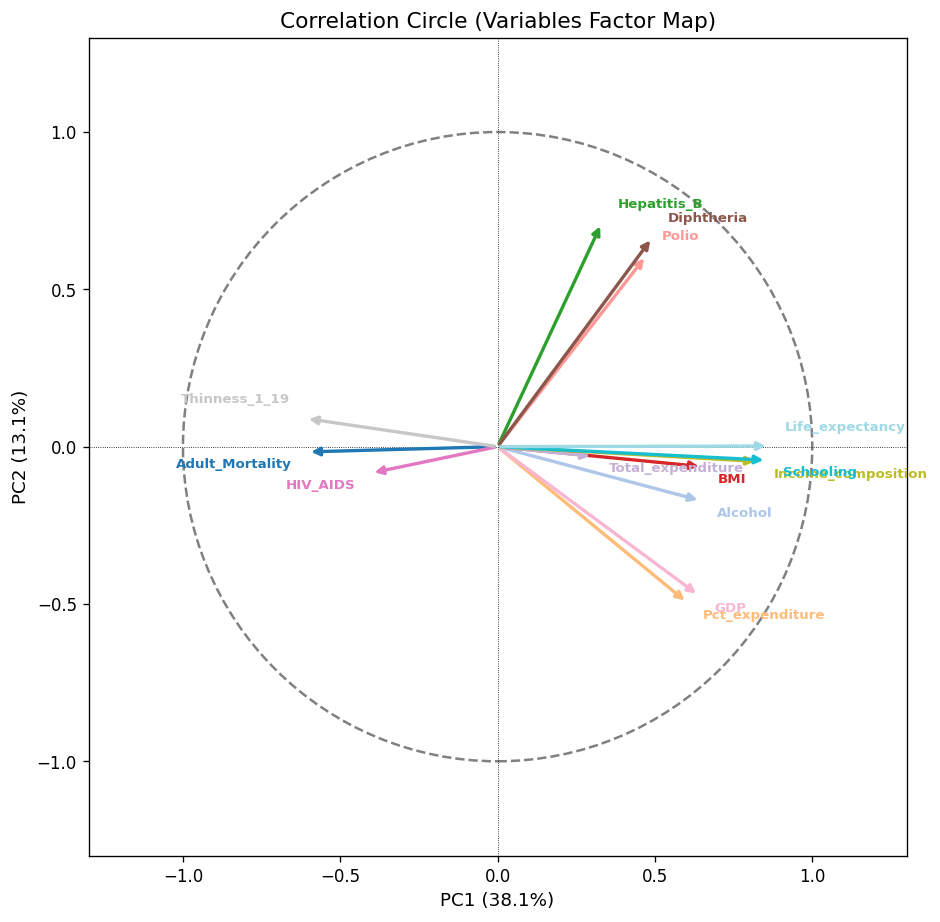

In [19]:
pca2     = PCA(n_components=2)
scores2  = pca2.fit_transform(X_pca_scaled)
loadings2 = pca2.components_.T
corr_circle = loadings2 * np.sqrt(pca2.explained_variance_)

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_patch(plt.Circle((0, 0), 1, color='gray', fill=False, lw=1.5, ls='--'))

colors_vars = plt.cm.tab20(np.linspace(0, 1, len(pca_cols)))
for i, (var, color) in enumerate(zip(pca_cols, colors_vars)):
    x, yc = corr_circle[i, 0], corr_circle[i, 1]
    ax.annotate("", xy=(x, yc), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
    ax.text(x + (0.05 if x >= 0 else -0.05),
            yc + (0.05 if yc >= 0 else -0.05),
            var, fontsize=8, color=color, fontweight='bold',
            ha='left' if x >= 0 else 'right')

ax.axhline(0, color='black', lw=0.5, ls=':')
ax.axvline(0, color='black', lw=0.5, ls=':')
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title("Correlation Circle (Variables Factor Map)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/09_correlation_circle.png", bbox_inches='tight')
plt.show()


## Data Projection onto First Two PCs

Left panel: colored by development status (Developed / Developing).  
Right panel: colored continuously by Life Expectancy value.


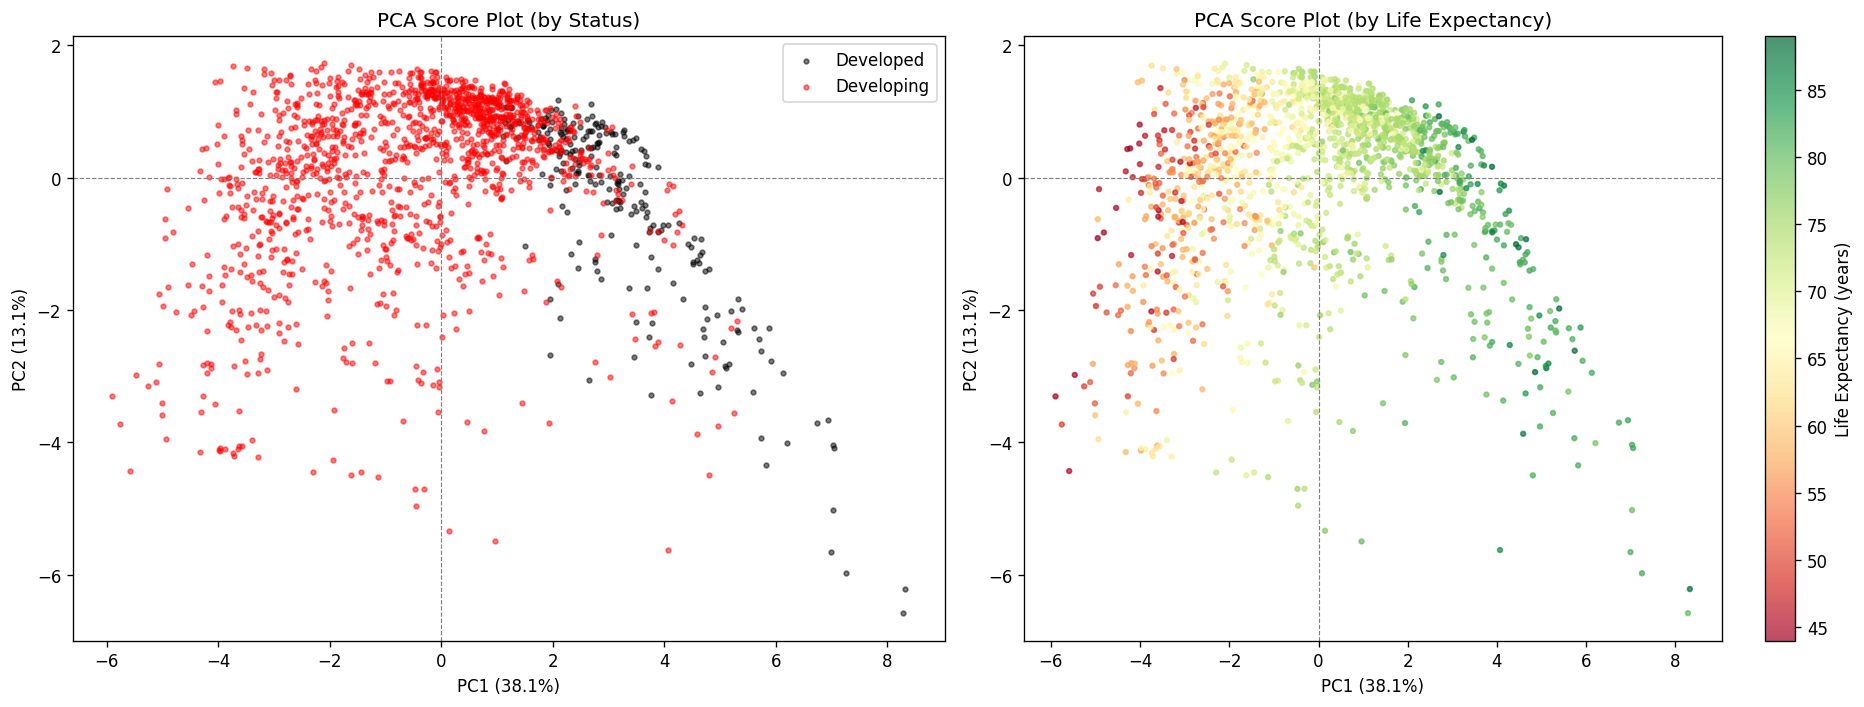

In [20]:
scores_df = pd.DataFrame(scores2, columns=["PC1", "PC2"])
scores_df["Status"]   = df_clean["Status"].values
scores_df["Life_exp"] = df_clean["Life_expectancy"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {"Developed": "black", "Developing": "red"}
for status, grp in scores_df.groupby("Status"):
    axes[0].scatter(grp["PC1"], grp["PC2"], s=8, c=palette[status],
                    alpha=0.5, label=status)
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].axvline(0, color='gray', lw=0.7, ls='--')
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA Score Plot (by Status)")
axes[0].legend()

sc = axes[1].scatter(scores_df["PC1"], scores_df["PC2"],
                     c=scores_df["Life_exp"], cmap='RdYlGn', s=8, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label="Life Expectancy (years)")
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].axvline(0, color='gray', lw=0.7, ls='--')
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA Score Plot (by Life Expectancy)")

plt.tight_layout()
plt.savefig("figures/10_pca_scores.png", bbox_inches='tight')
plt.show()


## K-Means Clustering + PCA Biplot

K-Means is applied to all standardized features to discover natural country groupings.
The optimal number of clusters is selected via the silhouette score.
The result is visualized as a **biplot**, combining the score plot (observations)
with loading arrows (variables) in the same PCA space.


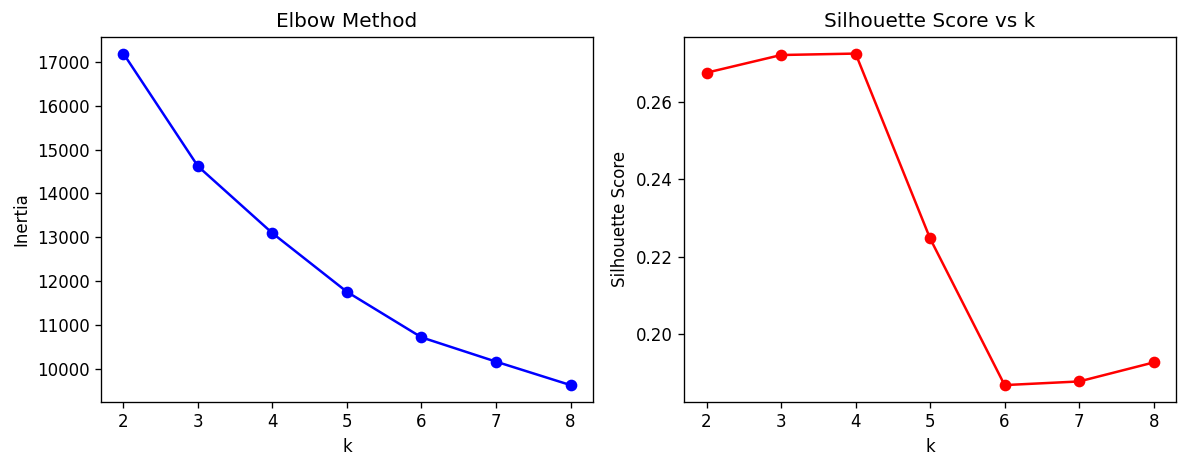

Best k by silhouette: 4


In [21]:
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X_pca_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_scaled, lab))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(K_range), inertias,   'bo-', ms=6)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[1].plot(list(K_range), silhouettes, 'ro-', ms=6)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
plt.tight_layout()
plt.savefig("figures/11a_kmeans_optimal_k.png", bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")


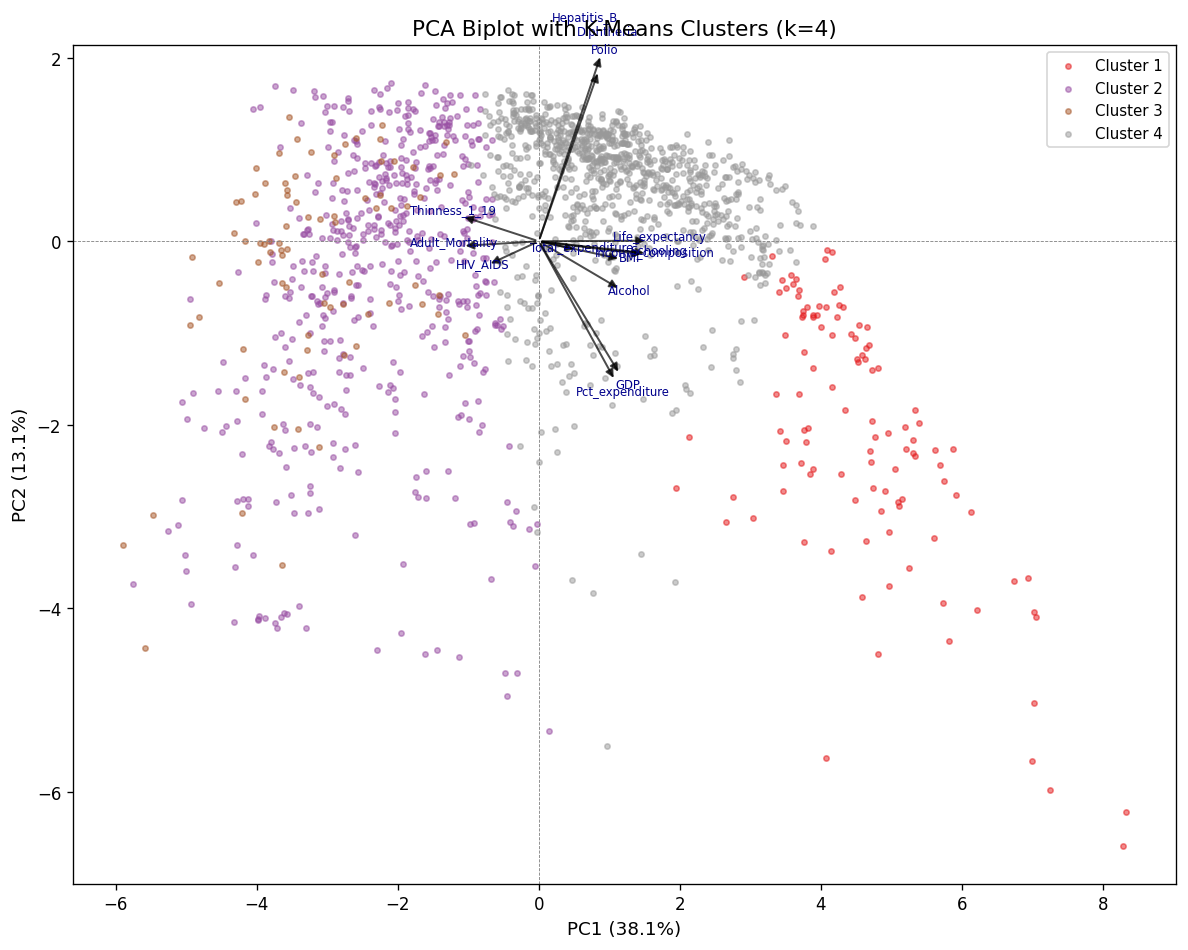

In [22]:
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca_scaled)

# Biplot
fig, ax = plt.subplots(figsize=(10, 8))
cmap_c = plt.cm.Set1(np.linspace(0, 1, best_k))
for c in range(best_k):
    mask = cluster_labels == c
    ax.scatter(scores2[mask, 0], scores2[mask, 1],
               s=10, color=cmap_c[c], alpha=0.5, label=f"Cluster {c+1}")

scale = np.max(np.abs(scores2)) * 0.5
for i, var in enumerate(pca_cols):
    ax.annotate("", xy=(loadings2[i, 0]*scale, loadings2[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2, alpha=0.7))
    ax.text(loadings2[i, 0]*scale*1.1, loadings2[i, 1]*scale*1.1,
            var, fontsize=7, color='darkblue', ha='center')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax.set_title(f"PCA Biplot with K-Means Clusters (k={best_k})", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/11b_pca_biplot_clusters.png", bbox_inches='tight')
plt.show()


In [23]:
# Cluster profiles
cluster_df = df_clean[pca_cols + ["Status"]].copy()
cluster_df["Cluster"] = cluster_labels

print("Mean values per cluster:")
display(cluster_df.groupby("Cluster")[pca_cols].mean().round(2))

print("\nStatus distribution per cluster:")
display(cluster_df.groupby(["Cluster", "Status"]).size().unstack(fill_value=0))


Mean values per cluster:


,Adult_Mortality,Alcohol,Pct_expenditure,Hepatitis_B,BMI,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Thinness_1_19,Income_composition,Schooling,Life_expectancy
Cluster,,,,,,,,,,,,,,
0,63.09,10.29,6093.24,77.76,53.01,94.12,7.26,94.24,0.10,40909.91,0.86,0.87,16.23,81.67
1,215.30,1.89,101.58,65.45,23.32,68.83,5.20,69.28,1.84,1114.40,8.01,0.45,9.49,62.56
2,471.40,4.16,191.00,74.35,24.73,78.62,6.74,78.26,24.54,1689.37,7.47,0.48,10.50,50.50
3,126.22,5.42,436.41,87.93,46.22,91.38,6.17,92.20,0.28,4211.01,3.25,0.72,13.31,73.44



Status distribution per cluster:


Status,Developed,Developing
Cluster,,
0,81,31
1,0,539
2,0,82
3,161,755


## Summary

In [24]:
n_pcs_80 = int(np.searchsorted(cumulative, 0.80)) + 1

summary = {
    "Observations (after NA drop)": df_clean.shape[0],
    "OLS R2":                        round(ols_model.rsquared, 4),
    "OLS Adj-R2":                    round(ols_model.rsquared_adj, 4),
    "Forward selection R2":          round(model_fwd.rsquared, 4),
    "LASSO features selected":       int((lasso_coefs != 0).sum()),
    "PCs for 80% variance":          n_pcs_80,
    "K-Means optimal k":             best_k,
}
pd.DataFrame.from_dict(summary, orient='index', columns=["Value"])


,Value
Observations (after NA drop),1649.0000
OLS R2,0.8257
OLS Adj-R2,0.8243
Forward selection R2,0.8252
LASSO features selected,10.0000
PCs for 80% variance,6.0000
K-Means optimal k,4.0000
